In [27]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import re
from xgboost import XGBClassifier
from sklearn.utils import resample
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
)

In [2]:
path = kagglehub.dataset_download("doanquanvietnamca/liar-dataset")
print("Path to dataset files:", path)

100%|█████████████████████████████████████████████████████████████████████████████| 0.98M/0.98M [00:00<00:00, 1.45MB/s]

Extracting files...
Path to dataset files: C:\Users\DELL\.cache\kagglehub\datasets\doanquanvietnamca\liar-dataset\versions\1


In [4]:
import os

dataset_folder = "C:\\Users\\DELL\\.cache\\kagglehub\\datasets\\doanquanvietnamca\\liar-dataset\\versions\\1"
print(os.listdir(dataset_folder))


['README', 'test.tsv', 'train.tsv', 'valid.tsv']


In [6]:
train_path = r"C:\Users\DELL\.cache\kagglehub\datasets\doanquanvietnamca\liar-dataset\versions\1\train.tsv"
valid_path = r"C:\Users\DELL\.cache\kagglehub\datasets\doanquanvietnamca\liar-dataset\versions\1\valid.tsv"
test_path = r"C:\Users\DELL\.cache\kagglehub\datasets\doanquanvietnamca\liar-dataset\versions\1\test.tsv"

train = pd.read_csv(train_path, sep="\t", header=None)
valid = pd.read_csv(valid_path, sep="\t", header=None)
test  = pd.read_csv(test_path,  sep="\t", header=None)


In [7]:
print(train.shape)
print(valid.shape)
print(test.shape)

(10240, 14)
(1284, 14)
(1267, 14)


In [8]:
df = pd.concat([train, valid], axis=0)

In [9]:
df.shape

(11524, 14)

In [10]:
columns = [
'id',
'label',
'statement',
'subject',
'speaker',
'speaker_job',
'state',
'party_affiliation',
'barely_true_counts',
'false_counts',
'half_true_counts',
'mostly_true_counts',
'pants_on_fire_counts',
'context'
]

df.columns = columns
test  = pd.read_csv(test_path,  sep="\t", header=None)
test.columns = columns

In [11]:
test.sample()

,id,label,statement,subject,speaker,speaker_job,state,party_affiliation,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context
1063,2594.json,true,John Raeses wife is registered to vote in Flor...,"candidates-biography,elections,message-machine",joe-manchin,Senator from West Virginia,West Virginia,democrat,0,0,1,1,0,a campaign ad


In [12]:
df = df[['statement','label','subject', 'party_affiliation']]
test2 = test[['statement','label','subject', 'party_affiliation']]

In [13]:
df.head(1)

,statement,label,subject,party_affiliation
0,Says the Annies List political group supports ...,false,abortion,republican


In [14]:
fake_labels = ['false','barely-true','pants-fire']

df['label'] = df['label'].apply(lambda x: 0 if x in fake_labels else 1)
test['label'] = test['label'].apply(lambda x: 0 if x in fake_labels else 1)

In [15]:
df['label'].value_counts()

label
1    6420
0    5104
Name: count, dtype: int64

## **EDA**

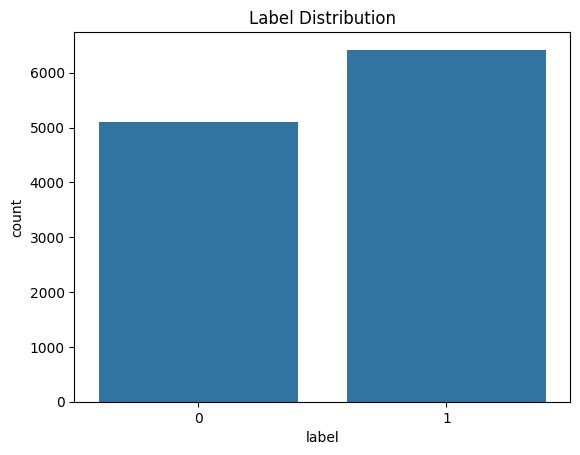

In [16]:
sns.countplot(x='label', data=df)
plt.title("Label Distribution")
plt.show()

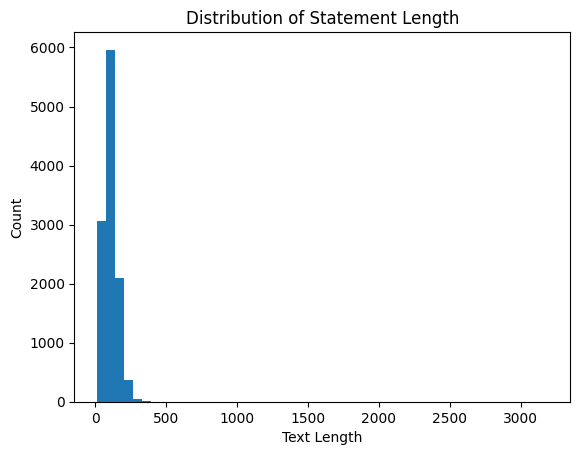

In [17]:
df['length'] = df['statement'].apply(len)

plt.hist(df['length'], bins=50)
plt.xlabel("Text Length")
plt.ylabel("Count")
plt.title("Distribution of Statement Length")
plt.show()

In [18]:
words = " ".join(df['statement']).lower().split()
freq = Counter(words)

print(freq.most_common(20))

[('the', 10945), ('in', 5632), ('of', 5359), ('to', 4999), ('a', 4086), ('and', 3120), ('says', 2649), ('for', 2332), ('that', 2017), ('is', 1959), ('on', 1672), ('has', 1423), ('have', 1392), ('than', 1248), ('are', 1244), ('percent', 1077), ('was', 1043), ('more', 1029), ('we', 1020), ('by', 971)]


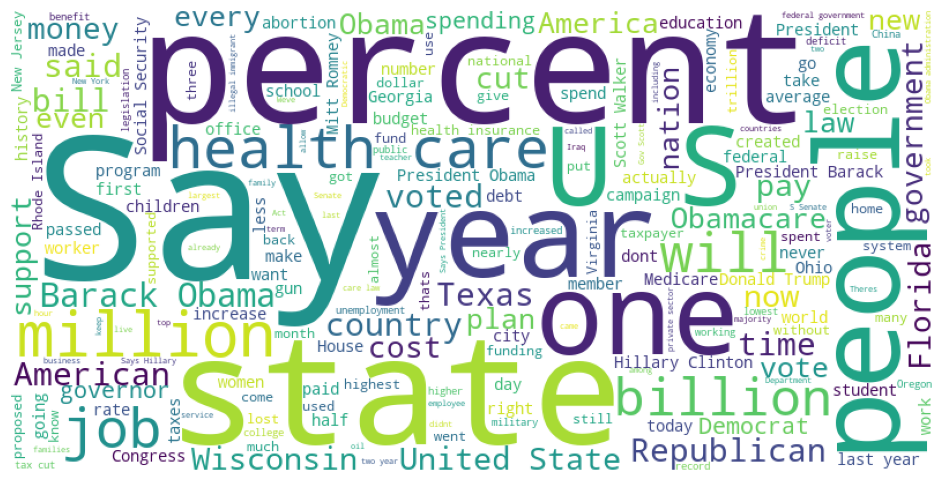

In [19]:
text_all = " ".join(df['statement'])

wordcloud = WordCloud(width=800,height=400,background_color='white').generate(text_all)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

## Preprocessing

In [21]:
def clean_text(text):
    text = str(text).lower() 
    text = re.sub(r"http\S+", "", text) 
    text = re.sub(r"@\w+", "", text)     
    text = re.sub(r"[^a-z\s]", "", text) 
    return text

for col in ['statement','subject','party_affiliation']:
    df[col+'_clean'] = df[col].apply(clean_text)
    test[col+'_clean'] = test[col].apply(clean_text)

In [22]:
df['combined_text'] = df['statement_clean'] + ' ' + df['subject_clean'] + ' ' + df['party_affiliation_clean']
test['combined_text'] = test['statement_clean'] + ' ' + test['subject_clean'] + ' ' + test['party_affiliation_clean']

In [23]:
df.sample()

,statement,label,subject,party_affiliation,length,statement_clean,subject_clean,party_affiliation_clean,combined_text
9918,Says Tom Barrett supports a government takeove...,0,"health-care,message-machine",republican,66,says tom barrett supports a government takeove...,healthcaremessagemachine,republican,says tom barrett supports a government takeove...


In [25]:
tfidf = TfidfVectorizer(max_features=8000, stop_words='english', ngram_range=(1,2))
X_train = tfidf.fit_transform(df['combined_text'])
X_test  = tfidf.transform(test['combined_text'])

y_train = df['label']
y_test  = test['label']

## Diementionality Reduction

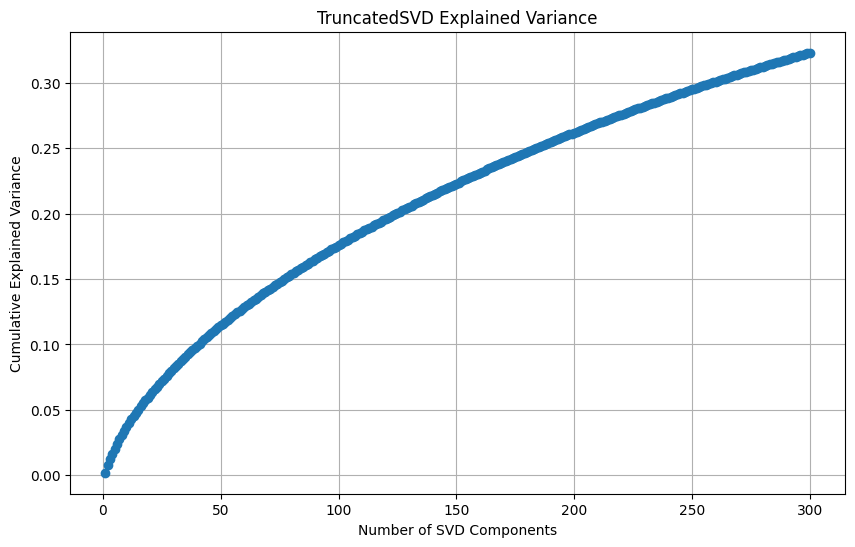

In [29]:
n_components = 300
svd = TruncatedSVD(n_components=n_components, random_state=42)
X_train_svd = svd.fit_transform(X_train)
X_test_svd  = svd.transform(X_test)


explained_variance = svd.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10,6))
plt.plot(range(1, n_components+1), cumulative_variance, marker='o')
plt.xlabel("Number of SVD Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("TruncatedSVD Explained Variance")
plt.grid(True)
plt.show()

## Naive Bayes Model

In [30]:
nb = MultinomialNB()
nb.fit(X_train, y_train) 
pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, pred_nb))
print(classification_report(y_test, pred_nb))

Naive Bayes Accuracy: 0.6337805840568271
              precision    recall  f1-score   support

           0       0.62      0.42      0.50       553
           1       0.64      0.80      0.71       714

    accuracy                           0.63      1267
   macro avg       0.63      0.61      0.61      1267
weighted avg       0.63      0.63      0.62      1267



## KNN Model

In [31]:
param_grid = {
    'n_neighbors': [5, 10, 15, 20, 25],
    'weights': ['uniform', 'distance'],
    'metric': ['minkowski', 'euclidean', 'manhattan']
}


knn = KNeighborsClassifier()


grid_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)


grid_knn.fit(X_train_svd, y_train)


best_knn = grid_knn.best_estimator_
print("Best KNN Parameters:", grid_knn.best_params_)


pred_knn = best_knn.predict(X_test_svd)
print("KNN Tuned Accuracy:", accuracy_score(y_test, pred_knn))
print(classification_report(y_test, pred_knn))

Best KNN Parameters: {'metric': 'minkowski', 'n_neighbors': 10, 'weights': 'distance'}
KNN Tuned Accuracy: 0.574585635359116
              precision    recall  f1-score   support

           0       0.51      0.56      0.54       553
           1       0.63      0.58      0.61       714

    accuracy                           0.57      1267
   macro avg       0.57      0.57      0.57      1267
weighted avg       0.58      0.57      0.58      1267



## Random Forest

In [32]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced'] 
}

# ===== Random Forest Model =====
rf = RandomForestClassifier(random_state=42)

# ===== Grid Search =====
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',  
    n_jobs=-1
)

# ===== Fit on SVD-reduced features =====
grid.fit(X_train_svd, y_train)


best_rf = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

# ===== Predict & Evaluate =====
pred_rf = best_rf.predict(X_test_svd)
print("Random Forest Tuned + Weighted Accuracy:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))




Best Parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Random Forest Tuned + Weighted Accuracy: 0.6053670086819258
              precision    recall  f1-score   support

           0       0.58      0.34      0.43       553
           1       0.61      0.81      0.70       714

    accuracy                           0.61      1267
   macro avg       0.60      0.58      0.56      1267
weighted avg       0.60      0.61      0.58      1267



## XGboost

In [33]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.01,
    scale_pos_weight=(len(y_train[y_train==0])/len(y_train[y_train==1])), 
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# ===== Fit on SVD-reduced features =====
xgb_model.fit(X_train_svd, y_train)

# ===== Predict & Evaluate =====
pred_xgb = xgb_model.predict(X_test_svd)

print("XGBoost Accuracy:", accuracy_score(y_test, pred_xgb))
print(classification_report(y_test, pred_xgb))

C:\Users\DELL\miniconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [02:54:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.5927387529597474
              precision    recall  f1-score   support

           0       0.53      0.56      0.55       553
           1       0.64      0.62      0.63       714

    accuracy                           0.59      1267
   macro avg       0.59      0.59      0.59      1267
weighted avg       0.60      0.59      0.59      1267



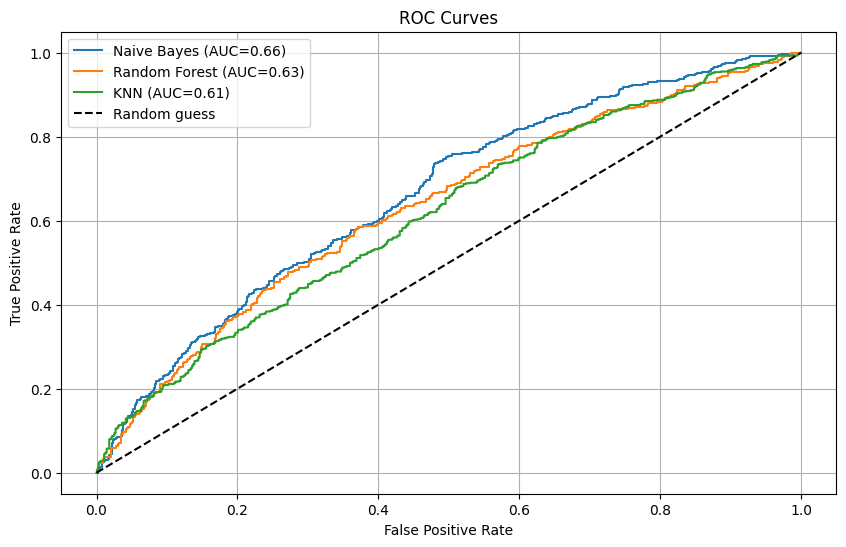

In [35]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0,1])

def plot_roc(model, X, name):
    y_prob = model.predict_proba(X)[:,1]
    fpr, tpr, _ = roc_curve(y_test_bin, y_prob)
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

fpr_nb, tpr_nb, auc_nb = plot_roc(nb, X_test, 'Naive Bayes')
fpr_rf, tpr_rf, auc_rf = plot_roc(best_rf, X_test_svd, 'Random Forest')
fpr_knn, tpr_knn, auc_knn = plot_roc(best_knn, X_test_svd, 'KNN')

plt.figure(figsize=(10,6))
plt.plot(fpr_nb,tpr_nb,label=f'Naive Bayes (AUC={auc_nb:.2f})')
plt.plot(fpr_rf,tpr_rf,label=f'Random Forest (AUC={auc_rf:.2f})')
plt.plot(fpr_knn,tpr_knn,label=f'KNN (AUC={auc_knn:.2f})')
plt.plot([0,1],[0,1],'k--',label='Random guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(True)
plt.show()